In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
import os
from scipy.optimize import curve_fit

from brokenaxes import brokenaxes

import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 300
from PythonAnalysis import *

In [2]:
def fit_loglog(values, i1, i2):
    """Fit log(<u u>) = log(C) - n*log(q) independently per replica, then
    combine the N_r independent fits into a mean (C, n) with SEM."""
    q_arr, hqn_arr = values          # each (N_unique, N_r)
    q_arr   = q_arr[i1:i2]
    hqn_arr = hqn_arr[i1:i2]
    N_r = q_arr.shape[1]

    params = np.empty((N_r, 2))      # columns: C, n
    for r in range(N_r):
        log_q   = np.log(q_arr[:, r])
        log_hqn = np.log(hqn_arr[:, r])
        slope, intercept = np.polyfit(log_q, log_hqn, 1)
        params[r] = [np.exp(intercept), -slope]

    #plt.hist(params[:,1])
    mean  = params.mean(axis=0)                    # [C_mean, n_mean]
    error = params.std(axis=0, ddof=1) / np.sqrt(N_r)  # SEM over replicas

    return params, mean, error

In [4]:
FTMethod = "DFT"
FrameTension="IsotropicFrameTension"
InitialConfiguration = "FromFlat"

N_k = 10
VFF="no"
i1 =0; i2 = 9

In [6]:
n_list = []
n_err_list = []
EPS_list = []
EPS_list.append(0)
kappa=20
EPS = "no"
Simulation = "OnlyMembrane"
AnalysisFile=f"{FrameTension}/{InitialConfiguration}/{Simulation}/kappa{kappa}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
DataFile=f"/lustre/astro/semygind/Data/MembraneInclusion/{FrameTension}/{InitialConfiguration}/{Simulation}/kappa{kappa}/VFF{VFF}/EPS{EPS}/"
data = load_boxsize_fourier_file(AnalysisFile)
values = data[('q','<u u>')]

params, mean, error = fit_loglog(values,i1=i1,i2=i2)
n_list.append(mean[1])
n_err_list.append(error[1])
print(f"C = {mean[0]:.4g} +/- {error[0]:.4g}")
print(f"n = {mean[1]:.4g} +/- {error[1]:.4g}")


C = 0.0469 +/- 0.002346
n = 3.786 +/- 0.05084


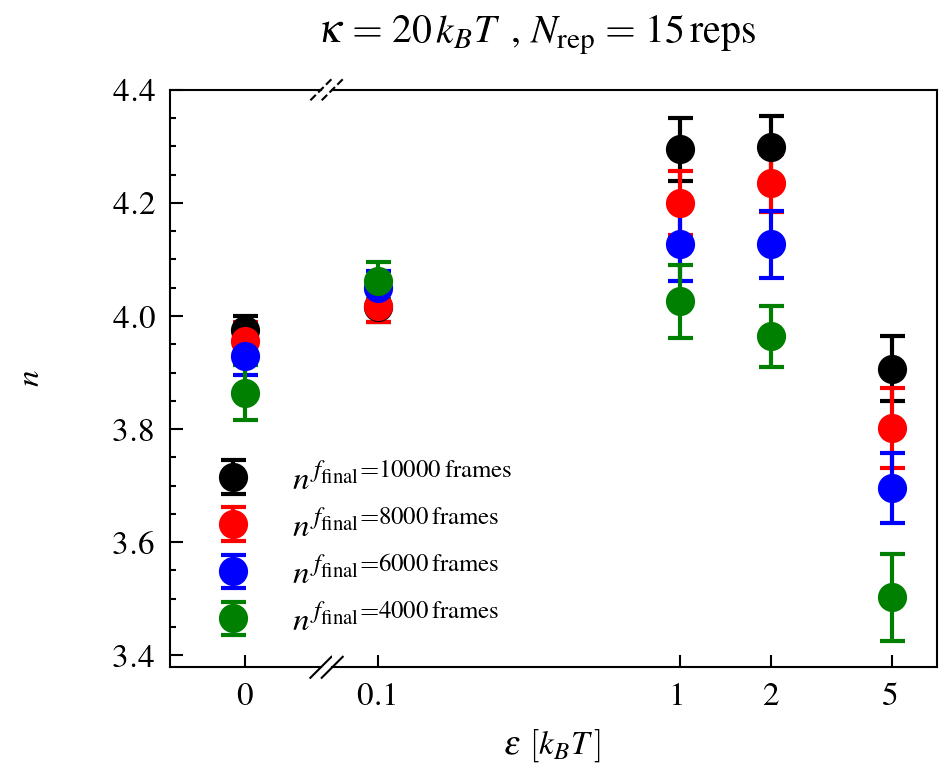

In [7]:
spectra = []
final_f_list = [10000,8000,6000,4000]

for final_f in final_f_list:
    spectra.extend([UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyMembrane",FTMethod,N_k=N_k,kappa=20,final_f=final_f),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_f=final_f, EPS="0.1"),           
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_f=final_f, EPS="1"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_f=final_f, EPS="2"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_f=final_f, EPS="5")])

UndulationSpectrum.plot_exponent(spectra, "I", i1, i2,x_var="EPS",GroupBy=["final_f"],legend=True)

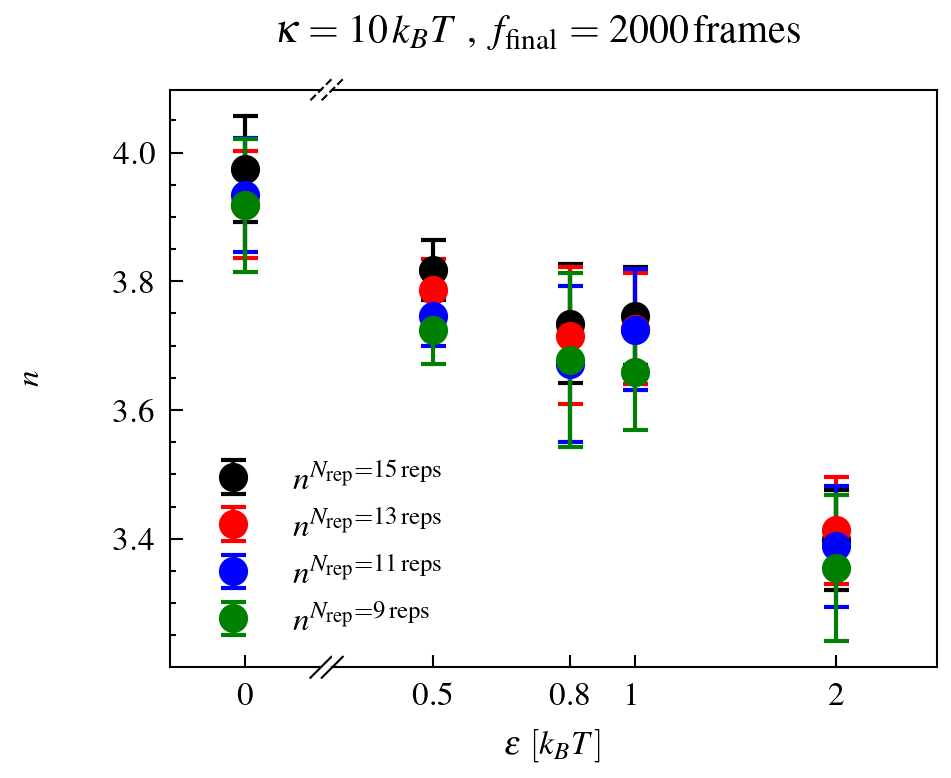

In [ ]:
spectra = []
final_f=2000
final_rep_list = [15,13,11,9]
for final_rep in final_rep_list:
    spectra.extend([UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyMembrane",FTMethod,N_k=N_k,kappa=10,final_f=final_f,final_rep=final_rep),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=10,final_f=final_f,final_rep=final_rep, EPS="0.5"),           
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=10,final_f=final_f,final_rep=final_rep, EPS="0.8"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=10,final_f=final_f,final_rep=final_rep, EPS="1"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=10,final_f=final_f,final_rep=final_rep, EPS="2")])

UndulationSpectrum.plot_exponent(spectra, "I", i1, i2,x_var="EPS",GroupBy=["final_rep"],legend=True)

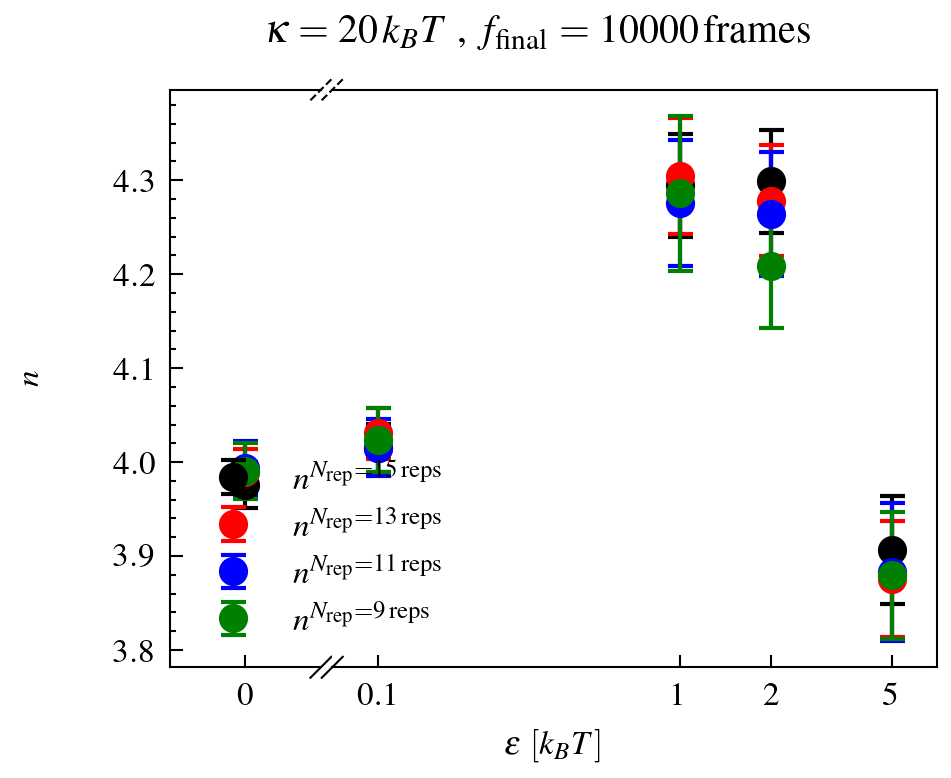

In [15]:
spectra = []
final_rep_list = [15,13,11,9]
for final_rep in final_rep_list:
    spectra.extend([UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyMembrane",FTMethod,N_k=N_k,kappa=20,final_rep=final_rep),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_rep=final_rep, EPS="0.1"),           
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_rep=final_rep, EPS="1"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_rep=final_rep, EPS="2"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,N_k=N_k,kappa=20,final_rep=final_rep, EPS="5")])

UndulationSpectrum.plot_exponent(spectra, "I", i1, i2,x_var="EPS",GroupBy=["final_rep"],legend=True)

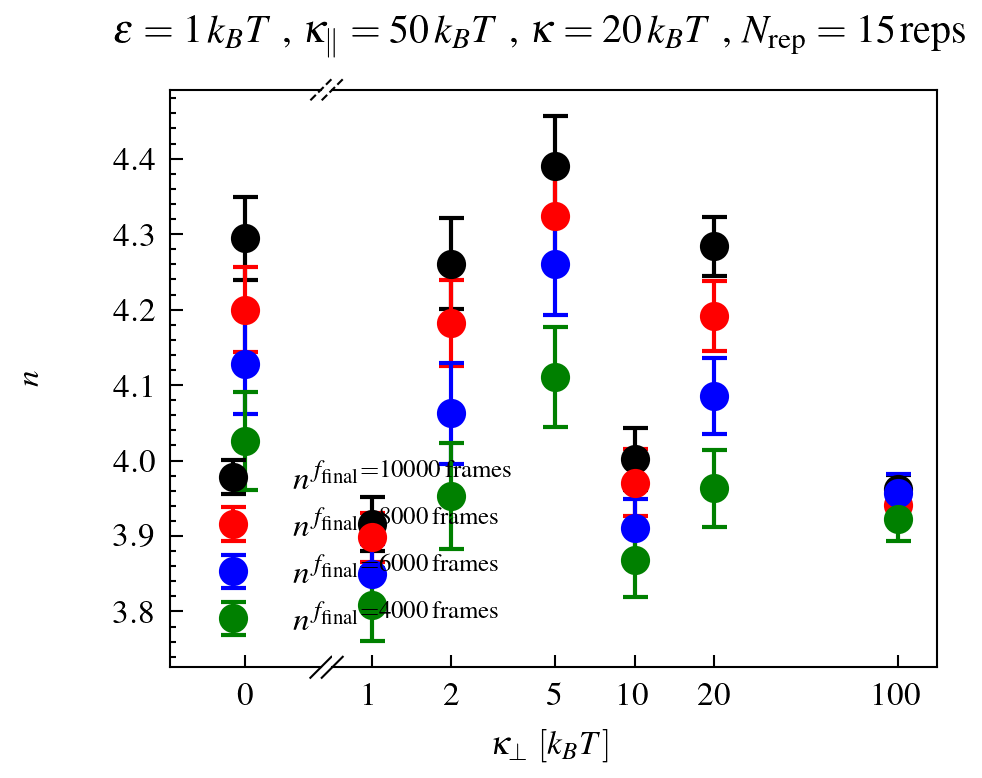

In [ ]:
spectra = []

EPS=1
final_f_list = [10000,8000,6000,4000]
for final_f in final_f_list:
    spectra.extend([UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",final_f=final_f,kappa=, EPS=f"{EPS}"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",final_f=final_f,kappa=, EPS=f"{EPS}",KP="1",KL="0.5"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",final_f=final_f,kappa=, EPS=f"{EPS}",KP="2",KL="1"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",final_f=final_f,kappa=, EPS=f"{EPS}",KP="5",KL="2.5"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",final_f=final_f,kappa=, EPS=f"{EPS}",KP="10",KL="5"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",final_f=final_f,kappa=, EPS=f"{EPS}",KP="",KL="10"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",final_f=final_f,kappa=, EPS=f"{EPS}",KP="100",KL="50")])
                #UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod, EPS="{EPS}"),
                #UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod, EPS="5")]

UndulationSpectrum.plot_exponent(spectra, "I", i1, i2,x_var="KP",GroupBy=["final_f"],legend=True)

FileNotFoundError: [Errno 2] No such file or directory: 'IsotropicFrameTension/FromFlat/OnlyVectorField/VFFno/EPS1/StaticUndulationSpectrum/DFT10/init_f150final_f10000_init_rep1final_rep15.txt'

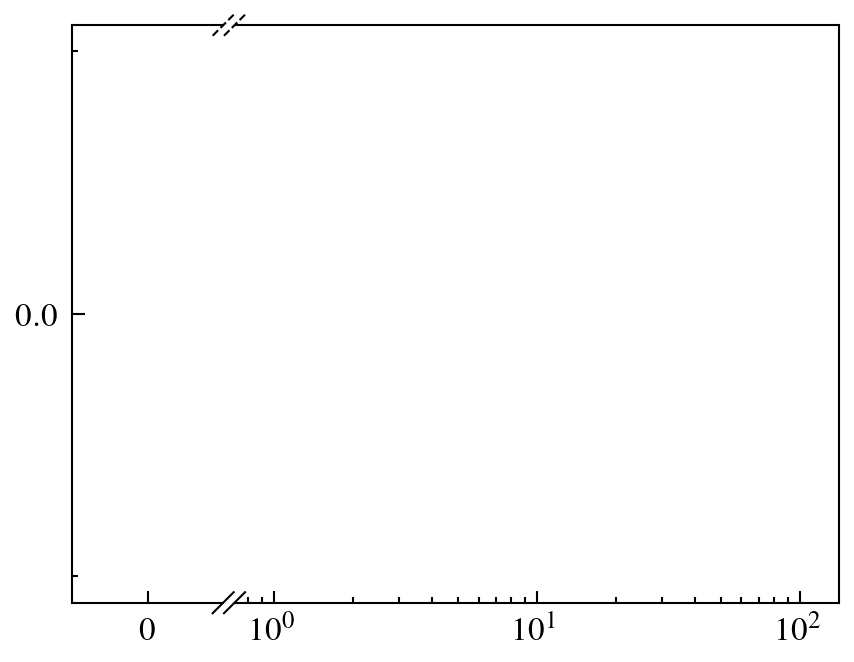

In [ ]:
spectra = []

EPS_list = [1]
for EPS in EPS_list:
    spectra.extend([UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod,  EPS=f"{EPS}"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",FTMethod, EPS=f"{EPS}",KP="1",KL="0.5"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",FTMethod, EPS=f"{EPS}",KP="2",KL="1"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",FTMethod, EPS=f"{EPS}",KP="5",KL="2.5"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",FTMethod, EPS=f"{EPS}",KP="10",KL="5"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",FTMethod, EPS=f"{EPS}",KP="",KL="10"),
                UndulationSpectrum(FrameTension,InitialConfiguration,"VFMCoupling",FTMethod, EPS=f"{EPS}",KP="100",KL="50")])
                #UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod, EPS="{EPS}"),
                #UndulationSpectrum(FrameTension,InitialConfiguration,"OnlyVectorField",FTMethod, EPS="5")]

UndulationSpectrum.plot_exponent(spectra, "I", i1, i2, x_var="KP", GroupBy=["EPS"], broken_axis=True,legend=False)

In [ ]:
Simulation0 = "OnlyMembrane"
EPS0 = "no"
AnalysisFile0 = f"{FrameTension}/{InitialConfiguration}/{Simulation0}/VFF{VFF}/EPS{EPS0}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
data0 = load_boxsize_fourier_file(AnalysisFile0)
values0 = data0[('q', '<u u>')]
_, mean0, error0 = fit_loglog(values0, i1=i1, i2=i2)

EPS_list = [0.1, 1, 2, 5, 10]
n_list = [mean0[1]]
n_err_list = [error0[1]]
Simulation = "OnlyVectorField"

for EPS in EPS_list:
    AnalysisFile = f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
    DataFile = f"/lustre/astro/semygind/Data/MembraneInclusion/{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/"
    data = load_boxsize_fourier_file(AnalysisFile)
    values = data[('q', '<u u>')]

    params, mean, error = fit_loglog(values, i1=i1, i2=i2)
    n_list.append(mean[1])
    n_err_list.append(error[1])

EPS_vals = np.array([0.0] + EPS_list, dtype=float)
n_arr = np.array(n_list)
n_err_arr = np.array(n_err_list)

eps_nonzero = np.sort(EPS_vals[EPS_vals > 0])

log_eps = np.log10(eps_nonzero)
log_pad = 0.15  # decades of breathing room around the data
right_xlim = (10 ** (log_eps.min() - log_pad), 10 ** (log_eps.max() + log_pad))

left_margin = eps_nonzero.min() * 0.01

fig = plt.figure()
bax = brokenaxes(
    xlims=((-left_margin, left_margin), right_xlim),
    width_ratios=[1, 4],
    wspace=0.03,   # panel gap: just enough room for the break marks, no dead space
    despine=False,  # keep the top/right box spines (default strips them)
)
bax.axs[1].set_xscale('log')

bax.errorbar(EPS_vals, n_arr, yerr=n_err_arr, fmt='o', capsize=3)
bax.hlines(4, -left_margin, right_xlim[1], linestyles='dashed', label=r"Helfrich Theory $n=4$")

bax.axs[0].set_xticks([0])
bax.axs[0].set_xticklabels(["0"])

# Show the actual EPS values as decimal ticks instead of 10^n scientific notation
bax.axs[1].set_xticks(eps_nonzero)
bax.axs[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:g}"))
bax.axs[1].xaxis.set_minor_locator(mticker.NullLocator())

#bax.text(0.05, 0.05, r'$f(q) = C\,q^{-n}$', transform=bax.transAxes,
#        verticalalignment='bottom', horizontalalignment='left')

# Give the y-axis some breathing room instead of the autoscaled limits
# clipping the top/bottom error bar caps against the frame
#y_lo = np.min(n_arr - n_err_arr)
#y_hi = np.max(n_arr + n_err_arr)
#y_pad = 0.1 * (y_hi - y_lo)
#for ax in bax.axs:
#    ax.set_ylim(y_lo - y_pad, y_hi + y_pad)

bax.set_xlabel(r"$\epsilon$")
bax.set_ylabel(r"$n$")
bax.set_title(rf"$\kappa = {kappa}k_BT$")
bax.legend(loc='lower left')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'IsotropicFrameTension/FromFlat/OnlyMembrane/VFFno/EPSno/StaticUndulationSpectrum/DFT10.txt'

# Bootstrap Table Method (from IsotropicOnlyVectorFieldTable.ipynb)

In [ ]:
def _fit_loglog_weighted(q, hqn_mean, hqn_error):
    """Single weighted log-log fit: log(hqn) = log(C) - n*log(q),
    weighted by the per-point error (delta method into log-space).
    Mirrors the (commented-out) fit_loglog helper in PythonAnalysis.py
    that IsotropicOnlyVectorFieldTable.ipynb's bootstrap() relies on."""
    log_q = np.log(q)
    log_y = np.log(hqn_mean)
    log_y_err = hqn_error / hqn_mean
    coeffs, cov = np.polyfit(log_q, log_y, 1, w=1/log_y_err, cov=True)
    n = -coeffs[0]
    C = np.exp(coeffs[1])
    return [C, n]

def fit_bootstrap(values, i1, i2, N_bootstrap=10000):
    """Bootstrap-fit method used in IsotropicOnlyVectorFieldTable.ipynb:
    resample replicas with replacement N_bootstrap times, weighted-fit
    each resampled mean curve (weights fixed from the un-resampled
    bootstrap_point_errors), then take mean/std of the resulting (C, n)
    across resamples. values: (q_arr, hqn_arr) tuple, each (N_unique, N_r)."""
    q_arr, hqn_arr = values
    q_arr   = q_arr[i1:i2]
    hqn_arr = hqn_arr[i1:i2]
    N_r = hqn_arr.shape[1]

    q = q_arr.mean(axis=1)
    hqn_error = bootstrap_point_errors(hqn_arr, N=N_bootstrap)

    bootstrap_params = []
    for _ in range(N_bootstrap):
        idx = np.random.choice(N_r, size=N_r, replace=True)
        hq_boot = hqn_arr[:, idx].mean(axis=1)
        bootstrap_params.append(_fit_loglog_weighted(q, hq_boot, hqn_error))
    bootstrap_params = np.array(bootstrap_params)  # (N_bootstrap, 2) -> C, n

    mean = bootstrap_params.mean(axis=0)
    error = bootstrap_params.std(axis=0, ddof=1)
    return mean, error

In [ ]:
# Compare against the bootstrap-fit method used in
# IsotropicOnlyVectorFieldTable.ipynb -- reuses the same `values` loaded
# above for OnlyMembrane.
mean_bootstrap, error_bootstrap = fit_bootstrap(values, i1=i1, i2=i2, N_bootstrap=10000)
print(f"[bootstrap]   C = {mean_bootstrap[0]:.4g} +/- {error_bootstrap[0]:.4g}")
print(f"[bootstrap]   n = {mean_bootstrap[1]:.4g} +/- {error_bootstrap[1]:.4g}")
print(f"[per-replica] C = {mean[0]:.4g} +/- {error[0]:.4g}")
print(f"[per-replica] n = {mean[1]:.4g} +/- {error[1]:.4g}")

[bootstrap]   C = 0.04095 +/- 0.001246
[bootstrap]   n = 3.893 +/- 0.02936
[per-replica] C = 0.05775 +/- 0.005389
[per-replica] n = 3.626 +/- 0.0838


In [ ]:
sims = [("OnlyMembrane", "no"), ("OnlyVectorField", "1"), ("OnlyVectorField", "2"),
        ("OnlyVectorField", "5"), ("OnlyVectorField", "10")]

EPS_vals = []
n_list = []
n_err_list = []
n_list_bootstrap = []
n_err_list_bootstrap = []

for Simulation, EPS in sims:
    AnalysisFile = f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
    DataFile = f"/lustre/astro/semygind/Data/MembraneInclusion/{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/"
    data = load_boxsize_fourier_file(AnalysisFile)
    values = data[('q', '<u u>')]

    params, mean, error = fit_loglog(values, i1=i1, i2=i2)
    n_list.append(mean[1])
    n_err_list.append(error[1])

    mean_bootstrap, error_bootstrap = fit_bootstrap(values, i1=i1, i2=i2, N_bootstrap=10000)
    n_list_bootstrap.append(mean_bootstrap[1])
    n_err_list_bootstrap.append(error_bootstrap[1])

    EPS_vals.append(0.0 if EPS == "no" else float(EPS))

EPS_vals = np.array(EPS_vals)
n_arr = np.array(n_list)
n_err_arr = np.array(n_err_list)
n_arr_bootstrap = np.array(n_list_bootstrap)
n_err_arr_bootstrap = np.array(n_err_list_bootstrap)

fig, ax = plt.subplots()
offset = 0.15  # small x-dodge so the two methods' errorbars don't overlap
ax.errorbar(EPS_vals - offset, n_arr, yerr=n_err_arr, fmt='o', capsize=3, label="per-replica (N=15)")
ax.errorbar(EPS_vals + offset, n_arr_bootstrap, yerr=n_err_arr_bootstrap, fmt='^', capsize=3, label="bootstrap (table method)")
ax.hlines(4, EPS_vals.min() - offset, EPS_vals.max() + offset, linestyles='dashed', label=r"Helfrich Theory $n=4$")
ax.set_xticks(EPS_vals)
ax.set_xticklabels(["no" if v == 0 else f"{v:g}" for v in EPS_vals])
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$n$")
ax.legend()
plt.show()

KeyboardInterrupt: 

# Group_Based Code




In [ ]:
def fit_loglog_grouped(values, i1, i2, N_groups=3):
    """Fit log(<u u>) = log(C) - n*log(q) on N_groups group-averaged
    curves (blocking the N_r replicas into N_groups consecutive chunks),
    weighting each fit by the within-group replica spread. Combine the
    N_groups independent fits into a mean (C, n) with SEM."""
    q_arr, hqn_arr = values          # each (N_unique, N_r)
    q_arr   = q_arr[i1:i2]
    hqn_arr = hqn_arr[i1:i2]
    N_r = q_arr.shape[1]
    group_size = N_r // N_groups

    params = np.empty((N_groups, 2))      # columns: C, n
    for g in range(N_groups):
        sel = slice(g * group_size, (g + 1) * group_size)
        n_g = hqn_arr[:, sel].shape[1]

        q_g       = q_arr[:, sel].mean(axis=1)
        hqn_g     = hqn_arr[:, sel].mean(axis=1)
        hqn_g_sem = hqn_arr[:, sel].std(axis=1, ddof=1) / np.sqrt(n_g)

        log_q     = np.log(q_g)
        log_hqn   = np.log(hqn_g)
        sigma_lnS = hqn_g_sem / hqn_g   # delta method: sigma_lnS ~ sigma_S / S

        slope, intercept = np.polyfit(log_q, log_hqn, 1, w=1/sigma_lnS)
        params[g] = [np.exp(intercept), -slope]

    mean  = params.mean(axis=0)                        # [C_mean, n_mean]
    error = params.std(axis=0, ddof=1) / np.sqrt(N_groups)  # SEM over groups

    return params, mean, error

In [ ]:
# Compare against grouping replicas into 3 blocks of 5 (rep 1-5, 6-10, 11-15)
# instead of fitting all 15 replicas independently -- reuses the same
# `values` loaded above for OnlyMembrane.
params_grouped, mean_grouped, error_grouped = fit_loglog_grouped(values, i1=i1, i2=i2, N_groups=3)
print(f"[grouped]     C = {mean_grouped[0]:.4g} +/- {error_grouped[0]:.4g}")
print(f"[grouped]     n = {mean_grouped[1]:.4g} +/- {error_grouped[1]:.4g}")
print(f"[per-replica] C = {mean[0]:.4g} +/- {error[0]:.4g}")
print(f"[per-replica] n = {mean[1]:.4g} +/- {error[1]:.4g}")

[grouped]     C = 0.04218 +/- 0.001283
[grouped]     n = 3.859 +/- 0.02616
[per-replica] C = 0.05775 +/- 0.005389
[per-replica] n = 3.626 +/- 0.0838


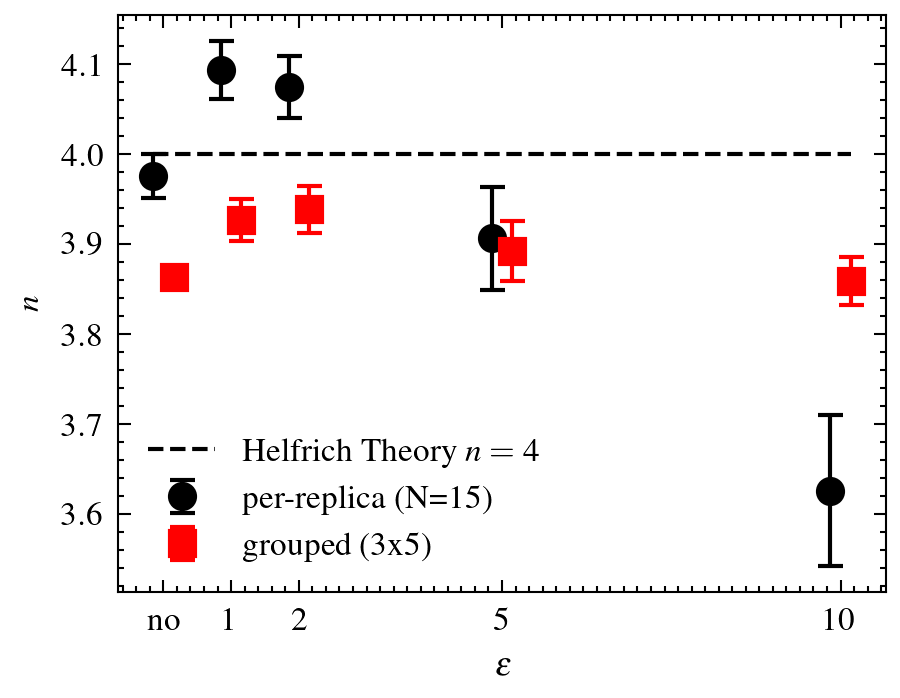

In [ ]:
sims = [("OnlyMembrane", "no"), ("OnlyVectorField", "1"), ("OnlyVectorField", "2"),
        ("OnlyVectorField", "5"), ("OnlyVectorField", "10")]

EPS_vals = []
n_list = []
n_err_list = []
n_list_grouped = []
n_err_list_grouped = []

for Simulation, EPS in sims:
    AnalysisFile = f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
    DataFile = f"/lustre/astro/semygind/Data/MembraneInclusion/{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/"
    data = load_boxsize_fourier_file(AnalysisFile)
    values = data[('q', '<u u>')]

    params, mean, error = fit_loglog(values, i1=i1, i2=i2)
    n_list.append(mean[1])
    n_err_list.append(error[1])

    params_grouped, mean_grouped, error_grouped = fit_loglog_grouped(values, i1=i1, i2=i2, N_groups=3)
    n_list_grouped.append(mean_grouped[1])
    n_err_list_grouped.append(error_grouped[1])

    EPS_vals.append(0.0 if EPS == "no" else float(EPS))

EPS_vals = np.array(EPS_vals)
n_arr = np.array(n_list)
n_err_arr = np.array(n_err_list)
n_arr_grouped = np.array(n_list_grouped)
n_err_arr_grouped = np.array(n_err_list_grouped)

fig, ax = plt.subplots()
offset = 0.15  # small x-dodge so the two methods' errorbars don't overlap
ax.errorbar(EPS_vals - offset, n_arr, yerr=n_err_arr, fmt='o', capsize=3, label="per-replica (N=15)")
ax.errorbar(EPS_vals + offset, n_arr_grouped, yerr=n_err_arr_grouped, fmt='s', capsize=3, label="grouped (3x5)")
ax.hlines(4, EPS_vals.min() - offset, EPS_vals.max() + offset, linestyles='dashed', label=r"Helfrich Theory $n=4$")
ax.set_xticks(EPS_vals)
ax.set_xticklabels(["no" if v == 0 else f"{v:g}" for v in EPS_vals])
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel(r"$n$")
ax.legend()
plt.show()